# **Statistical Learning on CASdatasets-$\texttt{fremotorclaim}$**

## **Modeling Claim Count $N$**
In the following `code` cells, we compress the data frame, leaving only the explanatory risk factors and total claim counts for each risk profile. We then fit the Poisson GLM with and without `year` as a risk factor. The **likelihood-ratio test** finds that `year` is a statistically significant risk factor ($\Lambda = 746.07$, $q=2$, $p \approx 9.830848\times 10^{-163}$). 

Further, we compute the ratio of expected claim counts across years holding other risk factors fixed. With `year = 7` as the baseline, years 8 and 9 have expected claim counts approximately 1.09 and 1.17 times that of year 7, respectively.

Finally, we split the data frame into training (years 7–8) and testing (year 9) datasets, with `year` encoded as numeric so the fitted  trend can be extrapolated to `year = 9`.

In [18]:
load("euMTPL.rda")
df_eu = euMTPL 
df_eu$year = factor(df_eu$year)
df_eu$num_fcd = df_eu$num_fcg
df_eu$cost_fcd = df_eu$cost_fcg  
df_eu$num = df_eu$num_fcd + df_eu$num_cd 
df_eu$cost = df_eu$cost_fcd + df_eu$cost_cd 
df_eu = df_eu[, c(1,3,4,5,6,8,9,10,11,22,23)]

In [19]:
dim(df_eu); head(df_eu); summary(df_eu)

[1] 2373197      11

,policy_id,fuel_type,year,vehicle_category,vehicle_use,horsepower,gender,age,exposure,num,cost
,<int>,<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<int>,<dbl>,<int>,<dbl>
1,1,B,7,1,1,14,M,77,0.48767123,0,0
2,2,B,7,1,1,12,M,40,0.01917808,0,0
3,4,B,7,1,1,14,M,75,0.03287671,0,0
4,5,B,7,1,1,13,M,48,0.04383562,0,0
5,6,B,7,1,1,12,F,54,0.04657534,0,0
6,8,B,7,1,1,12,F,34,0.07671233,0,0


   policy_id         fuel_type       year       vehicle_category vehicle_use 
 Min.   :      1   B      :1382612   7:788932   1:2360481        0 :  12670  
 1st Qu.: 641820   D      : 531255   8:789367   8:  12716        1 :2359462  
 Median :1280437   G      : 383832   9:794898                    4 :    145  
 Mean   :1290070   T      :  29637                               5 :    518  
 3rd Qu.:1939574   P      :  19289                               26:    402  
 Max.   :2595214   S      :  15131                                           
                   (Other):  11441                                           
   horsepower     gender           age            exposure     
 Min.   :  0.00   F: 893348   Min.   : 18.00   Min.   :0.0010  
 1st Qu.: 14.00   M:1479849   1st Qu.: 37.00   1st Qu.:0.3005  
 Median : 16.00               Median : 46.00   Median :0.6822  
 Mean   : 16.52               Mean   : 48.17   Mean   :0.6266  
 3rd Qu.: 19.00               3rd Qu.: 59.00   3rd Qu.:1

In [20]:
# poisson.fit.full = glm(num ~ fuel_type + year + vehicle_category + vehicle_use + horsepower + gender + age + offset(log(exposure)), family = poisson, df_eu)
# poisson.fit.reduced = glm(num ~ fuel_type + vehicle_category + vehicle_use + horsepower + gender + age + offset(log(exposure)), family = poisson, df_eu)

In [21]:
# saveRDS(poisson.fit.full, "fitted.model.full.rds")
# saveRDS(poisson.fit.reduced, "fit.model.reduced.rds")
# file.exists("fitted.model.full.rds")
# file.exists("fit.model.reduced.rds")

In [22]:
fit.full = readRDS("fitted.model.full.rds")
fit.reduced = readRDS("fit.model.reduced.rds")

In [23]:
anova(fit.reduced, fit.full, test = "LRT") 

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2373181,951495.1,NA,NA,NA
2,2373179,950749.0,2,746.0717,9.830848e-163


In [24]:
coefs = summary(fit.full)$coefficients
year_coefs = coefs[grep("year", rownames(coefs)), ]
contrasts(df_eu$year); exp(year_coefs[, "Estimate"]) #contrasts() shows that year 7 is the baseline.

,8,9
7,0,0
8,1,0
9,0,1


year8    year9 
1.094518 1.169947

In [25]:
df_train = df_eu[df_eu$year %in% c("7", "8"), ]
df_test = df_eu[df_eu$year == "9", ]

### **Fitting Poisson GLM to the training dataset**
#### **Preliminary Diagnostics & Covariate Screening**
We first check if there is correlation between continuous risk factors `horsepower` and `age`. Then, we check the collinearity via VIF and GVIF after fitting the full model. 

In [26]:
cor(df_train$age, df_train$horsepower, use = "pairwise.complete.obs")

[1] -0.06689502

In [27]:
# Convert year to numeric linear trend for trend modeling
df_train$year = as.numeric(as.character(df_train$year))
df_test$year = as.numeric(as.character(df_test$year))

fit.count.train = glm(num ~ fuel_type + year + vehicle_category + vehicle_use + horsepower + gender + age + offset(log(exposure)), family = poisson, df_train)

In [28]:
library(car)
vif(fit.count.train)
table(df_train$vehicle_category, df_train$vehicle_use)

,GVIF,Df,GVIF^(1/(2*Df))
fuel_type,1.087908,7,1.006036
year,1.001289,1,1.000644
vehicle_category,215.952293,1,14.695315
vehicle_use,216.167740,4,1.958163
horsepower,1.026551,1,1.013189
gender,1.067572,1,1.033234
age,1.060263,1,1.029691


   
          0       1       4       5      26
  1       0 1568588      79     328     276
  8    9002       0       5      21       0

#### **Variable Selection**
Since the VIF of `vehicle_category` and `vehicle_use` are unusually high, we drop `vehicle_category` and fit the model again. This resolves the collinearity, and VIF's of all present factors are now roughly 1.

In [29]:
fit.count.train.update = glm(num ~ fuel_type + year + vehicle_use + horsepower + gender + age + offset(log(exposure)), family = poisson, df_train)
vif(fit.count.train.update)

,GVIF,Df,GVIF^(1/(2*Df))
fuel_type,1.087895,7,1.006036
year,1.001289,1,1.000644
vehicle_use,1.003780,4,1.000472
horsepower,1.026548,1,1.013187
gender,1.067566,1,1.033231
age,1.060262,1,1.029690


#### **Outliers and Influential Points**
We first compute the leverages, then the residual. 

In [30]:
h = hatvalues(fit.count.train.update)
p = length(coef(fit.count.train.update))
n = nrow(df_train)
lev_thresh = 3 * (p / n)
high_leverage_idx = which(h > lev_thresh)
length(high_leverage_idx)

[1] 42408

In [31]:
r_pearson = residuals(fit.count.train.update, type = "pearson") / sqrt(1 - h)
outlier_idx = which(abs(r_pearson) > 3)
length(outlier_idx)

[1] 50823

### **Model Significance & Goodness-of-Fit Assessment**
The following `code` provide the results of **Likelihood-Ratio Test**, **Deviance Goodness-of-Fit Test** and **Pearson's Chi-Squared Test** respectively.

#### **Overall Model Significance (Likelihood-Ratio Test)**
$p$-value being essentialy $0$ shows that our risk factors actually have predictive power.

In [58]:
dif.dev = fit.count.train.update$null.deviance - fit.count.train.update$deviance
dif.df = fit.count.train.update$df.null - fit.count.train.update$df.residual
p_val_lrt = pchisq(dif.dev, df = dif.df, lower.tail = FALSE)
dif.dev; dif.df; p_val_lrt
fit.count.train.update$df.null
fit.count.train.update$df.residual

[1] 4148.62

[1] 15

[1] 0

[1] 1578298

[1] 1578283

#### **Model Specification (Deviance Goodness-of-Fit Test)**
$p$-value being approximately 1 could suggest the Poisson GLM is well specified, but we treat this with caution — see the "Final Verdict" discussion below regarding the reliability of this test under sparse fitted means.

In [33]:
dev = fit.count.train.update$deviance
df_res = fit.count.train.update$df.residual
p_val_gof = pchisq(dev, df = df_res, lower.tail = FALSE)
dev; p_val_gof

[1] 610732.1

[1] 1

#### **Overdispersion (Pearson Chi-Squared Test)**
The large value of X2 shows that sum of squared standardised errors is large, and the estimate of the dispersion parameter (`est.phi = 1.27`) is the evidence of dispersion. 

In [34]:
fit.val = predict(fit.count.train.update, newdata = df_train, type = 'response')
X2 = sum((fit.val-df_train$num)^2/fit.val) #sum of squared standardised errors
df_train_residual = fit.count.train.update$df.residual
p_val_X2 = pchisq(X2, df = df_train_residual, lower.tail = FALSE)
est.phi = X2/df_train_residual #estimate of dispersion parameter
X2; p_val_X2; est.phi

[1] 2010375

[1] 0

[1] 1.273773

## **Modeling Claim Severity $Y_j$**
In the following `code` cells we first remove individuals with 0 claim. Then, we compute the average claim amounts for each individual. 

In [42]:
df_sev = df_eu[df_eu$num > 0, ] # remove insureds with no claim
df_sev$sev = df_sev$cost/df_sev$num #average claim amount
df_sev = df_sev[, c(1,2,3,4,5,6,7,8,10,12)]
df_sev$year = as.numeric(as.character(df_sev$year))
df_train_sev = df_sev[df_sev$year %in% c("7", "8"), ]
df_test_sev = df_sev[df_sev$year == "9", ]
head(df_sev)

,policy_id,fuel_type,year,vehicle_category,vehicle_use,horsepower,gender,age,num,sev
,<int>,<fct>,<dbl>,<fct>,<fct>,<int>,<fct>,<int>,<int>,<dbl>
1,44,B,7,1,1,12,F,31,1,1800
2,182,B,7,1,1,18,M,45,1,1800
3,196,B,7,1,1,18,F,74,1,1800
4,215,D,7,1,1,19,F,60,1,2000
5,396,B,7,1,1,15,M,60,1,2000
6,463,B,7,1,1,12,M,29,1,2300


### **Fitting Gamma GLM**

In [51]:
fit.sev.train = glm(sev ~ fuel_type + year + vehicle_use + vehicle_category + horsepower + gender + age, family = Gamma(link = "log"), weights = num, data = df_train_sev)
vif(fit.sev.train)
summary(fit.sev.train)

,GVIF,Df,GVIF^(1/(2*Df))
fuel_type,1.197008,7,1.012927
year,1.001151,1,1.000575
vehicle_use,217.522474,4,1.959693
vehicle_category,217.088731,1,14.733931
horsepower,1.172956,1,1.083031
gender,1.064878,1,1.031929
age,1.043834,1,1.021682



Call:
glm(formula = sev ~ fuel_type + year + vehicle_use + vehicle_category + 
    horsepower + gender + age, family = Gamma(link = "log"), 
    data = df_train_sev, weights = num)

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        8.1347725  0.3641445  22.339  < 2e-16 ***
fuel_typeD        -0.0252861  0.0046017  -5.495 3.92e-08 ***
fuel_typeE         0.0306979  0.2496761   0.123 0.902146    
fuel_typeG         0.0237788  0.0051392   4.627 3.72e-06 ***
fuel_typeM         0.0290115  0.0289030   1.004 0.315500    
fuel_typeP         0.0497213  0.0205660   2.418 0.015623 *  
fuel_typeS         0.0298330  0.0254196   1.174 0.240550    
fuel_typeT        -0.0165162  0.0159904  -1.033 0.301662    
year              -0.1277694  0.0035953 -35.538  < 2e-16 ***
vehicle_use1       0.4249873  0.3630484   1.171 0.241759    
vehicle_use4       0.9275050  0.4303634   2.155 0.031151 *  
vehicle_use5       0.4038309  0.3538937   1.141 0.253828    
vehicle_us

#### **Variable Selection**
As for the Claim count $N$, we also detect collinearity in `vehicle_use` and `vehicle_category`. By dropping `vehicle_category`, the collinearity is resolved.

In [ ]:
fit.sev.train.update = glm(sev ~ fuel_type + year + vehicle_use + horsepower + gender + age, family = Gamma(link = "log"), weights = num, data = df_train_sev)
vif(fit.sev.train.update)
summary(fit.sev.train.update)

,GVIF,Df,GVIF^(1/(2*Df))
fuel_type,1.196969,7,1.012925
year,1.001150,1,1.000575
vehicle_use,1.005796,4,1.000723
horsepower,1.172954,1,1.083030
gender,1.064867,1,1.031924
age,1.043822,1,1.021676


[1] 0.3738948

#### **Goodness-of-Fit Diagnostics**
We provide two QQ-plots to see if our model is well specified. 

[1] 0.3738948

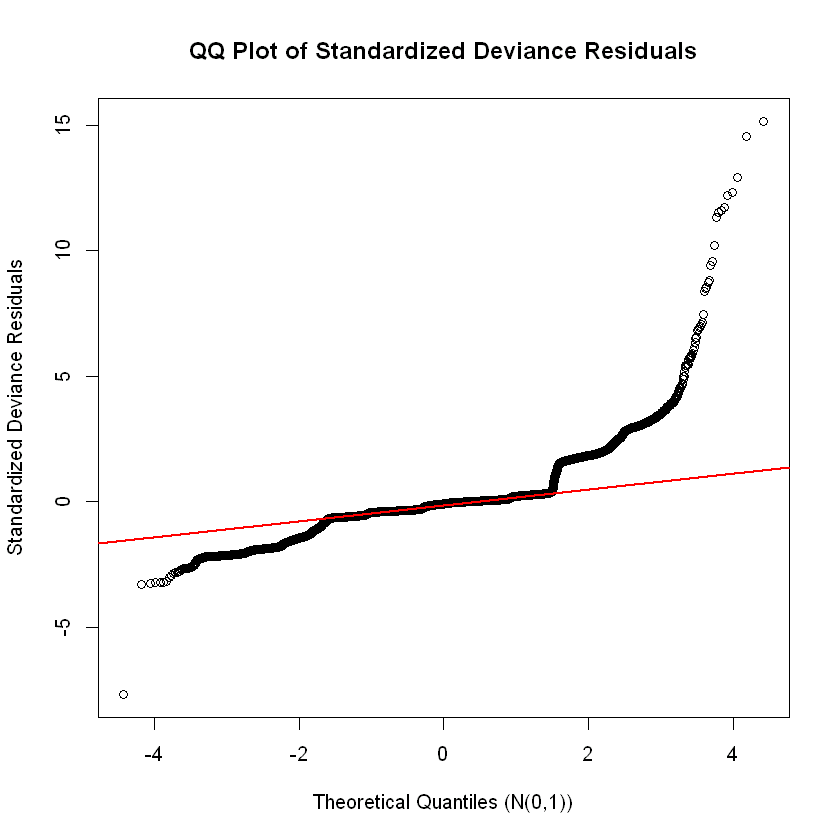

In [55]:
phi.hat = summary(fit.sev.train.update)$dispersion
resid.dev = residuals(fit.sev.train.update, type = "deviance")
resid.std = resid.dev / sqrt(phi.hat)
phi.hat
qqnorm(resid.std, 
       main = "QQ Plot of Standardized Deviance Residuals",
       xlab = "Theoretical Quantiles (N(0,1))",
       ylab = "Standardized Deviance Residuals")
qqline(resid.std, col = "red", lwd = 2)

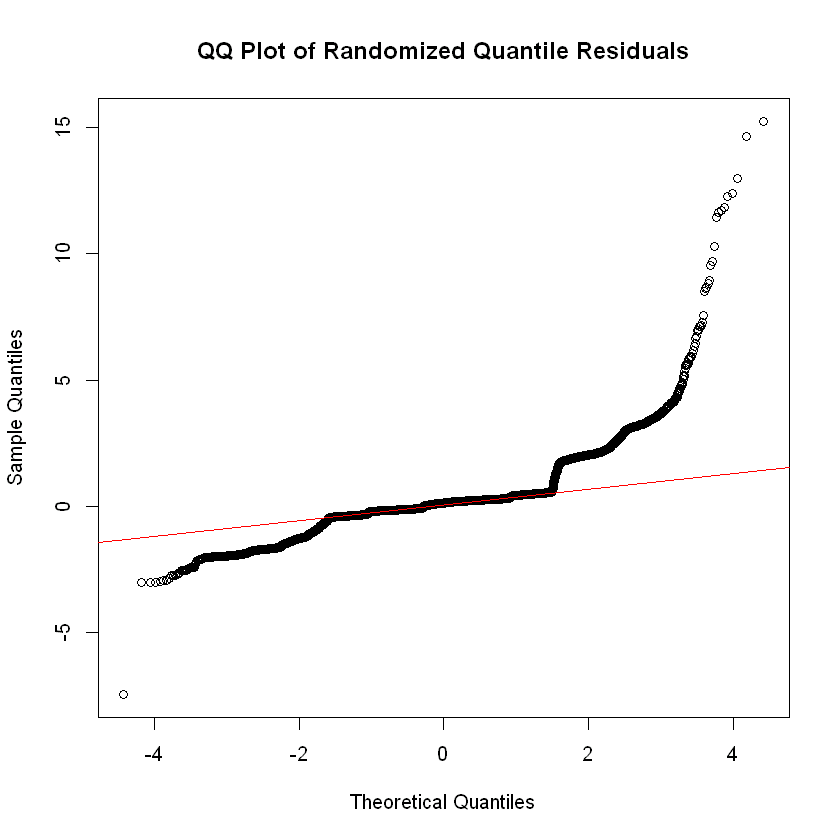

In [57]:
library(statmod)

qres = qresid(fit.sev.train.update)  # randomized quantile residuals

qqnorm(qres, main = "QQ Plot of Randomized Quantile Residuals")
qqline(qres, col = "red")